In [2]:
import sys
from pathlib import Path
import os

# Dynamically resolve the project root and add it to the system path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Standardized directories for notebook usage
DATA_DIR = PROJECT_ROOT / 'data'
MODELS_DIR = PROJECT_ROOT / 'models'

In [2]:
import pandas as pd 

def load_data(path: str) -> pd.DataFrame:
    return pd.read_excel(path)


data = load_data(path = os.path.join(DATA_DIR, 'OCC DJ DT june.xlsx'))
print(data.shape)
data.head()


(34, 10)


,מלון,תאריך הזמנה,חדרים למכירה,חדרים תפוסים,אחוז תפוסה,ADR Actual Net,ADR Gross Actual,RevPAR,אחוז ישראלים,אחוז תיירים
0,Dan Jerusalem,2026-06-01,505,21.0,0.041584,868.739048,1000.467619,36.125782,0.904762,0.095238
1,Dan Jerusalem,2026-06-02,505,14.0,0.027723,-78.402857,-185.481429,-2.173545,0.928571,0.071429
2,Dan Jerusalem,2026-06-03,505,10.0,0.019802,469.167000,528.613000,9.290436,0.900000,0.100000
3,Dan Jerusalem,2026-06-04,505,422.0,0.835644,806.582607,961.868863,674.015564,0.997630,0.000000
4,Dan Jerusalem,2026-06-05,505,480.0,0.950495,1006.861500,1436.711812,957.016871,0.997917,0.000000


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_theme(style = "whitegrid")

df = pd.read_excel(os.path.join(DATA_DIR, 'Master.xlsx')) 
df['Date'] = pd.to_datetime(df['Date'])
df = df[df['Date'].dt.year != 2018].reset_index(drop = True)
df.head()

,Date,Year,Month,Day_Of_Week,Is_Weekend,Is_Holiday,Hotel_ID,Occupied_Rooms,Total_Rooms,Occupancy_Rate,...,Total_Reception_Employees,Total_Room_Services_Hours,Total_Room_Services_Employees,Total_Security_Hours,Total_Security_Employees,Total_Waiters_Hours,Total_Waiters_Employees,Percentage_of_Israelis,Percentage_of_Tourists,Key
0,2019-01-01,2019,1,Tuesday,0,New Year's Day,DJ,275.82,505.0,0.546178,...,6,8.82,1,108.24,15,235.08,32,0.025379,0.974621,01/01/2019DJ
1,2019-01-01,2019,1,Tuesday,0,New Year's Day,DT,155.00,293.0,0.529010,...,6,29.09,4,35.97,5,7.55,1,0.019355,0.896774,01/01/2019DT
2,2019-01-02,2019,1,Wednesday,0,0,DJ,402.92,505.0,0.797861,...,11,7.82,1,117.18,16,342.78,45,0.009928,0.990072,02/01/2019DJ
3,2019-01-02,2019,1,Wednesday,0,0,DT,137.00,293.0,0.467577,...,5,61.78,7,37.40,4,0.00,0,0.014599,0.890511,02/01/2019DT
4,2019-01-03,2019,1,Thursday,0,0,DJ,428.88,505.0,0.849267,...,9,7.48,1,92.19,13,230.69,32,0.030312,0.962694,03/01/2019DJ


In [5]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
data_analysis = df[['Date', 'Hotel_ID', 'Total_Household_Hours', 'Total_Household_Employees', 'Total_Kitchen_Hours',
       'Total_Kitchen_Employees', 'Total_Waiters_Hours', 'Total_Waiters_Employees', 'Occupied_Rooms', 'Occupancy_Rate']]

data_analysis['Hour_Waiter_per_employee'] = (data_analysis['Total_Waiters_Hours'] / data_analysis['Total_Waiters_Employees']).round(2)
data_analysis['Hour_Kitchen_per_employee'] = (data_analysis['Total_Kitchen_Hours'] / data_analysis['Total_Kitchen_Employees']).round(2)
data_analysis['Hour_Household_per_employee'] = (data_analysis['Total_Household_Hours'] / data_analysis['Total_Household_Employees']).round(2)
data_analysis = data_analysis.fillna(0)
data_analysis.head()

,Date,Hotel_ID,Total_Household_Hours,Total_Household_Employees,Total_Kitchen_Hours,Total_Kitchen_Employees,Total_Waiters_Hours,Total_Waiters_Employees,Occupied_Rooms,Occupancy_Rate,Hour_Waiter_per_employee,Hour_Kitchen_per_employee,Hour_Household_per_employee
0,2019-01-01,DJ,313.59,40,425.81,56,235.08,32,275.82,0.546178,7.35,7.60,7.84
1,2019-01-01,DT,234.53,30,366.00,49,7.55,1,155.00,0.529010,7.55,7.47,7.82
2,2019-01-02,DJ,333.92,45,419.79,54,342.78,45,402.92,0.797861,7.62,7.77,7.42
3,2019-01-02,DT,246.57,33,448.77,56,0.00,0,137.00,0.467577,0.00,8.01,7.47
4,2019-01-03,DJ,374.16,47,416.74,54,230.69,32,428.88,0.849267,7.21,7.72,7.96


In [7]:
print(data_analysis.Hour_Waiter_per_employee.mean())
print(data_analysis.Hour_Kitchen_per_employee.mean())
print(data_analysis.Hour_Household_per_employee.mean())

7.169769260852561
7.9347379741885025
7.912514665623777


In [9]:
data_analysis = data_analysis[data_analysis.Total_Waiters_Employees != 0]
data_summary = pd.DataFrame()
data_summary['Waiter_Occupied_Rooms_Rate'] = ((data_analysis['Total_Waiters_Employees'] / data_analysis['Occupied_Rooms']) * 100).round(2)
data_summary['Kitchen_Occupied_Rooms_Rate'] = ((data_analysis['Total_Kitchen_Employees'] / data_analysis['Occupied_Rooms']) * 100).round(2)
data_summary['Household_Occupied_Rooms_Rate'] = ((data_analysis['Total_Household_Employees'] / data_analysis['Occupied_Rooms']) * 100).round(2)
data_summary

,Waiter_Occupied_Rooms_Rate,Kitchen_Occupied_Rooms_Rate,Household_Occupied_Rooms_Rate
0,11.60,20.30,14.50
1,0.65,31.61,19.35
2,11.17,13.40,11.17
4,7.46,12.59,10.96
6,8.72,14.22,10.78
...,...,...,...
5109,18.86,23.77,18.04
5110,17.07,43.90,56.10
5111,19.84,19.84,19.84
5112,10.23,18.61,7.44


In [10]:
data_analysis['DayName'] = data_analysis.Date.dt.day_name()

In [11]:
data_analysis['DayName'] = data_analysis.Date.dt.day_name()
orders = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
data_agg = data_analysis.groupby('DayName')[['Total_Waiters_Employees', 'Total_Kitchen_Employees', 'Total_Household_Employees']].mean()
data_agg = data_agg.reindex(orders)

data_agg

,Total_Waiters_Employees,Total_Kitchen_Employees,Total_Household_Employees
DayName,,,
Monday,23.658094,30.204236,32.222390
Tuesday,23.867378,30.471037,31.849085
Wednesday,24.270106,32.295903,32.684370
Thursday,25.135952,33.829305,34.377644
Friday,28.705882,32.217806,33.829889
Saturday,25.271860,25.531002,27.635930
Sunday,22.256098,28.626524,33.452744


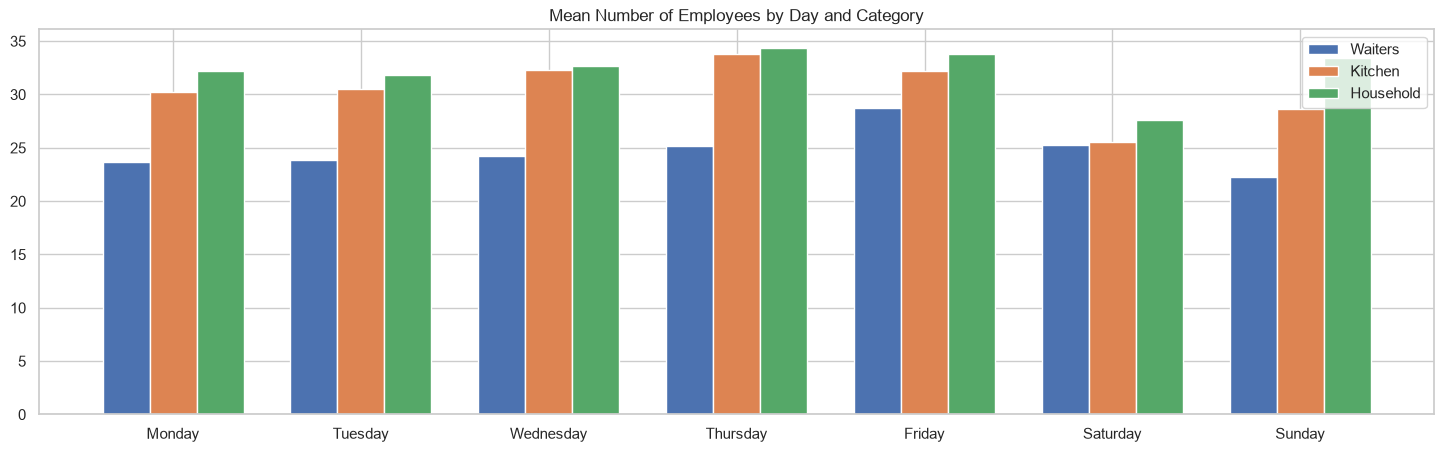

In [12]:
import numpy as np
x = np.arange(len(data_agg))
width = 0.25 

plt.figure(figsize=(18, 5))
plt.bar(x - width, data_agg['Total_Waiters_Employees'], width = width, label='Waiters')
plt.bar(x, data_agg['Total_Kitchen_Employees'], width = width, label='Kitchen')
plt.bar(x + width, data_agg['Total_Household_Employees'], width = width, label='Household')
plt.xticks(x, data_agg.index)
plt.title("Mean Number of Employees by Day and Category")
plt.legend()
plt.show()


ANALYSE HÔTEL : DT

--- HOUSEKEEPING : Ratio Statistics (Employees per 100 Rooms) per Day ---
            Mean  Median  Optimal_25p    Max
DayName                                     
Monday     20.11   18.62        15.22  41.38
Tuesday    19.87   18.37        14.74  42.50
Wednesday  20.75   19.63        15.16  42.86
Thursday   17.88   16.68        13.53  39.18
Friday     15.85   15.31        12.40  35.00
Saturday   22.47   21.84        16.35  42.50
Sunday     22.29   20.82        16.50  42.86


/var/folders/f4/fbx90hv150q4_678jhcc2xz40000gn/T/ipykernel_4161/2432306650.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_clean.groupby('DayName')['Housekeeping_Rate'].agg(
/var/folders/f4/fbx90hv150q4_678jhcc2xz40000gn/T/ipykernel_4161/2432306650.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DayName', y='Housekeeping_Rate', data=df_clean, palette="Blues")
/var/folders/f4/fbx90hv150q4_678jhcc2xz40000gn/T/ipykernel_4161/2432306650.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.

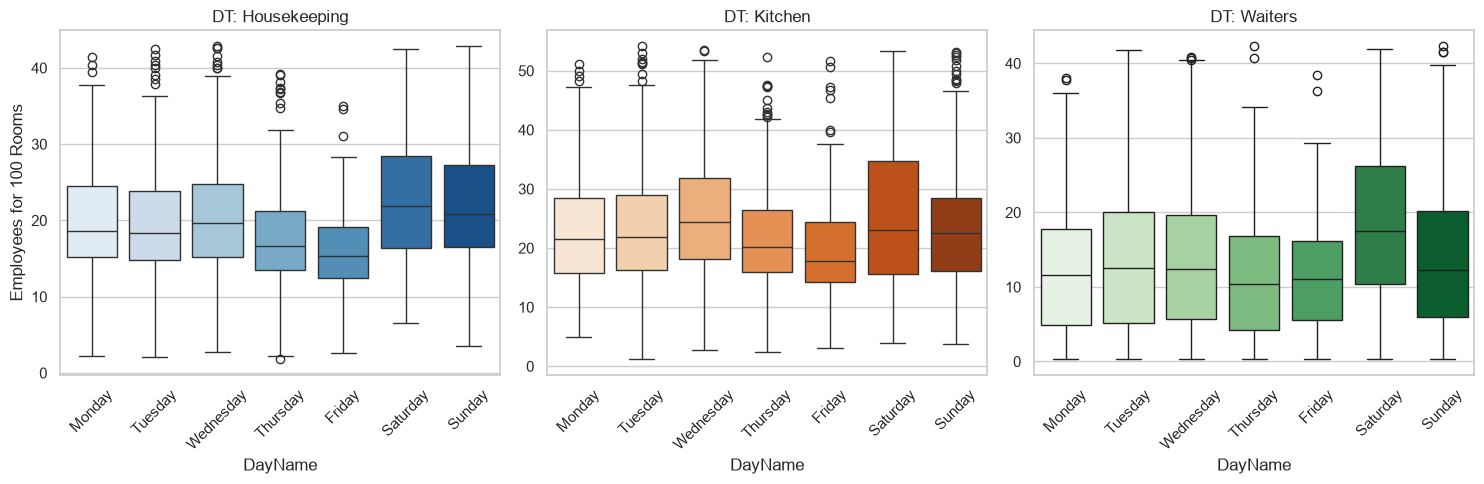


ANALYSE HÔTEL : DJ

--- HOUSEKEEPING : Ratio Statistics (Employees per 100 Rooms) per Day ---
            Mean  Median  Optimal_25p    Max
DayName                                     
Monday     15.45   14.11        12.28  33.84
Tuesday    15.06   13.49        11.52  32.15
Wednesday  15.56   13.69        11.34  33.13
Thursday   14.89   13.94        11.65  33.71
Friday     12.46   11.97         9.97  30.79
Saturday   16.02   13.88        11.56  34.16
Sunday     16.96   15.23        12.59  33.34


/var/folders/f4/fbx90hv150q4_678jhcc2xz40000gn/T/ipykernel_4161/2432306650.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df_clean.groupby('DayName')['Housekeeping_Rate'].agg(
/var/folders/f4/fbx90hv150q4_678jhcc2xz40000gn/T/ipykernel_4161/2432306650.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DayName', y='Housekeeping_Rate', data=df_clean, palette="Blues")
/var/folders/f4/fbx90hv150q4_678jhcc2xz40000gn/T/ipykernel_4161/2432306650.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.

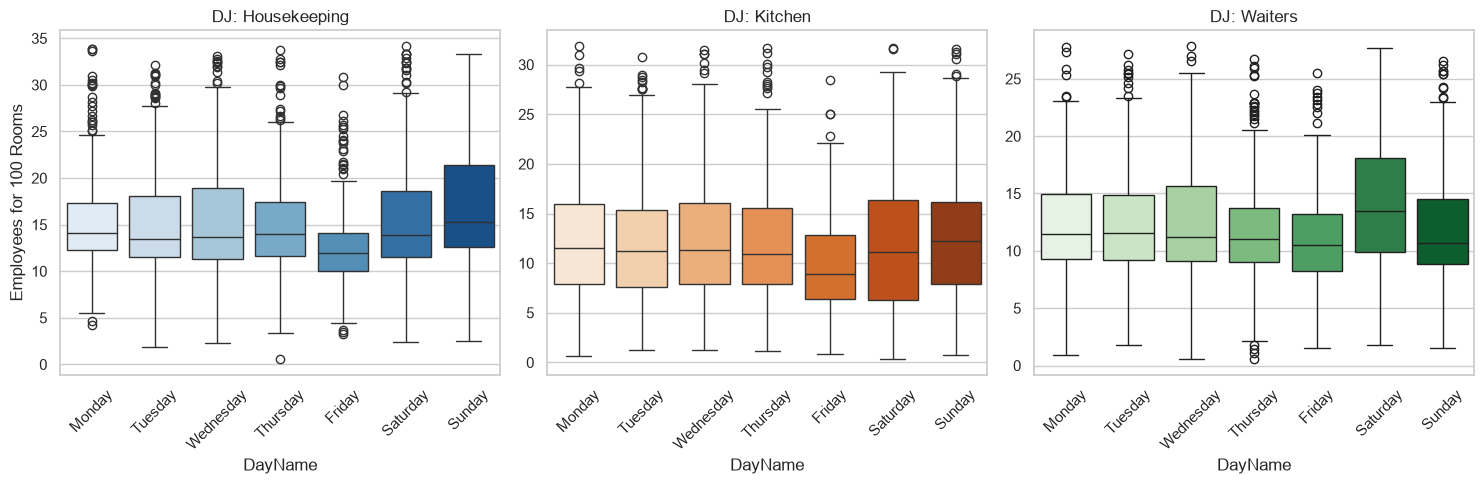

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="whitegrid")

# --- 1. Chargement et Préparation ---
# Assure-toi que DATA_DIR est défini
df = pd.read_excel(os.path.join(DATA_DIR, 'Master.xlsx')) 
df['Date'] = pd.to_datetime(df['Date'])
df = df[(df['Date'].dt.year != 2018) & (df['Occupied_Rooms'] > 15)].reset_index(drop=True)

# --- 2. Calcul des Ratios par chambre (Employés / 100 Chambres Occupées) ---
# Multiplier par 100 permet de lire "Combien d'employés pour 100 chambres" (plus lisible)
df['Housekeeping_Rate'] = (df['Total_Household_Employees'] / df['Occupied_Rooms']) * 100
df['Kitchen_Rate'] = (df['Total_Kitchen_Employees'] / df['Occupied_Rooms']) * 100
df['Waiters_Rate'] = (df['Total_Waiters_Employees'] / df['Occupied_Rooms']) * 100

df['DayName'] = df['Date'].dt.day_name()
orders = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['DayName'] = pd.Categorical(df['DayName'], categories=orders, ordered=True)

# --- 3. Fonction pour nettoyer les Outliers extrêmes (Méthode IQR) ---
def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

for hotel in ['DT', 'DJ']:
    print(f"\n{'='*40}")
    print(f"Analyze Hotel : {hotel}")
    print(f"{'='*40}")
    
    df_hotel = df[df['Hotel_ID'] == hotel].copy()
    
    df_hotel = df_hotel.dropna(subset=['Housekeeping_Rate', 'Kitchen_Rate', 'Waiters_Rate'])
    df_hotel = df_hotel[(df_hotel['Housekeeping_Rate'] > 0) & (df_hotel['Kitchen_Rate'] > 0) & (df_hotel['Waiters_Rate'] > 0)]
    df_clean = remove_outliers(df_hotel, 'Housekeeping_Rate')
    
    print("\n--- HOUSEKEEPING : Ratio Statistics (Employees per 100 Rooms) per Day ---")
    stats = df_clean.groupby('DayName')['Housekeeping_Rate'].agg(
        Mean='mean', 
        Median='median', 
        Optimal_25p=lambda x: x.quantile(0.25),  # Le top 25% des jours les plus efficients
        Max = 'max' 
    ).round(2)
    print(stats)
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    sns.boxplot(x='DayName', y='Housekeeping_Rate', data=df_clean, palette="Blues")
    plt.title(f'{hotel}: Housekeeping')
    plt.ylabel('Employees for 100 Rooms')
    plt.xticks(rotation=45)
    
    plt.subplot(1, 3, 2)
    df_k_clean = remove_outliers(df_hotel, 'Kitchen_Rate')
    sns.boxplot(x='DayName', y='Kitchen_Rate', data=df_k_clean, palette="Oranges")
    plt.title(f'{hotel}: Kitchen')
    plt.ylabel('')
    plt.xticks(rotation=45)
    
    plt.subplot(1, 3, 3)
    df_w_clean = remove_outliers(df_hotel, 'Waiters_Rate')
    sns.boxplot(x='DayName', y = 'Waiters_Rate', data=df_w_clean, palette="Greens")
    plt.title(f'{hotel}: Waiters')
    plt.ylabel('')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

In [ ]:
import math
import pandas as pd
from typing import Dict

# --- 1. CONFIGURATION DES RÈGLES MÉTIERS (Les "תקנים") ---

# Ratios de Haute Efficacité (Optimal_25p) issus de l'EDA
# Lecture : "Pour 100 chambres, il faut X employés"
EFFICIENCY_TARGETS = {
    'DT': {
        'Housekeeping': {'Monday': 15.22, 'Tuesday': 14.74, 'Wednesday': 15.16, 'Thursday': 13.53, 'Friday': 12.40, 'Saturday': 16.35, 'Sunday': 16.50},
        'Kitchen':      {'Monday': 18.00, 'Tuesday': 18.00, 'Wednesday': 20.00, 'Thursday': 16.00, 'Friday': 15.00, 'Saturday': 18.00, 'Sunday': 16.00}, # À ajuster via ton EDA
        'Waiters':      {'Monday': 10.00, 'Tuesday': 10.00, 'Wednesday': 10.00, 'Thursday': 8.00,  'Friday': 15.00, 'Saturday': 12.00, 'Sunday': 10.00}  # À ajuster via ton EDA
    },
    'DJ': {
        'Housekeeping': {'Monday': 12.28, 'Tuesday': 11.52, 'Wednesday': 11.34, 'Thursday': 11.65, 'Friday': 9.97,  'Saturday': 11.56, 'Sunday': 12.59},
        'Kitchen':      {'Monday': 10.00, 'Tuesday': 10.00, 'Wednesday': 10.00, 'Thursday': 9.00,  'Friday': 8.00,  'Saturday': 9.00,  'Sunday': 10.00}, # À ajuster via ton EDA
        'Waiters':      {'Monday': 10.00, 'Tuesday': 10.00, 'Wednesday': 10.00, 'Thursday': 9.00,  'Friday': 18.00, 'Saturday': 14.00, 'Sunday': 10.00}  # À ajuster via ton EDA
    }
}

# Seuils Minimums Incompressibles (Tafkid Barzel / Minimum Staff) 
# Même avec 0 client, l'hôtel doit payer ce personnel
MINIMUM_STAFF = {
    'DT': {'Housekeeping': 10, 'Kitchen': 5, 'Waiters': 3},
    'DJ': {'Housekeeping': 8,  'Kitchen': 4, 'Waiters': 3}
}

# --- 2. LE MOTEUR D'OPTIMISATION ---

def optimize_staffing(hotel_id: str, target_date: str, predicted_upper_bound_rooms: int) -> Dict[str, int]:
    """
    Calcule le nombre optimal d'employés à planifier pour respecter la qualité 
    tout en minimisant le gaspillage, en utilisant l'intervalle de sécurité.
    """
    day_name = pd.to_datetime(target_date).day_name()
    recommendations = {}
    
    for dept in ['Housekeeping', 'Kitchen', 'Waiters']:
        # 1. Contrainte de Qualité (La norme historique haute performance)
        ratio_optimal = EFFICIENCY_TARGETS[hotel_id][dept][day_name]
        employees_for_quality = (predicted_upper_bound_rooms / 100.0) * ratio_optimal
        
        # 2. Contrainte Légale/Fixe (Le minimum syndical de l'hôtel)
        minimum_required = MINIMUM_STAFF[hotel_id][dept]
        
        # 3. Résolution (Minimisation sous contraintes)
        # On prend le maximum entre le besoin qualité et le seuil incompressible, et on arrondit à l'entier supérieur
        optimal_employees = math.ceil(max(employees_for_quality, minimum_required))
        
        recommendations[dept] = optimal_employees
        
    return recommendations


# --- 3. TEST DU MOTEUR (À exécuter directement) ---
if __name__ == "__main__":
    print("=== TEST DU MOTEUR D'OPTIMISATION RH ===")
    
    # Scénario : L'IA a prédit 280 chambres (borne haute) pour un Vendredi à Tel Aviv
    # On sait que le vendredi, le nettoyage est rapide (12.4 employés pour 100 chambres)
    rec_vendredi = optimize_staffing('DT', '2026-09-04', 280) # 4 Sept = Vendredi
    print(f"\nRecommandation DT - Vendredi (280 chambres) :")
    print(f"Housekeeping: {rec_vendredi['Housekeeping']} employés")
    
    # Scénario : L'IA a prédit 280 chambres (borne haute) pour un Dimanche à Tel Aviv
    # On sait que le dimanche, le nettoyage est lourd (16.5 employés pour 100 chambres)
    rec_dimanche = optimize_staffing('DT', '2026-09-06', 280) # 6 Sept = Dimanche
    print(f"\nRecommandation DT - Dimanche (280 chambres) :")
    print(f"Housekeeping: {rec_dimanche['Housekeeping']} employés")

=== TEST DU MOTEUR D'OPTIMISATION RH ===

Recommandation DT - Vendredi (280 chambres) :
Housekeeping: 35 employés

Recommandation DT - Dimanche (280 chambres) :
Housekeeping: 47 employés
